# ⚡ Boosting Pipeline — Used Cars Price Classification

**Ensemble Method:** Boosting via **XGBoost · LightGBM · Gradient Boosting**

**Target:** Price category (Budget / Mid-range / Premium / Luxury)

**Metrics:** Accuracy · F1 · Precision · Recall · ROC-AUC · Confusion Matrix · Classification Report


## 1. Imports & Setup

In [15]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder, OneHotEncoder, label_binarize
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve, auc,
    ConfusionMatrixDisplay
)
import xgboost as xgb
import lightgbm as lgb

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.family': 'DejaVu Sans'})

SEED = 42
print('Libraries loaded ✓')

Libraries loaded ✓


## 2. Load & Preview Data

In [16]:
df = pd.read_csv('used_cars.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (4009, 12)


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [17]:
print('--- Data Types ---')
print(df.dtypes)
print('\n--- Missing Values ---')
print(df.isnull().sum())

--- Data Types ---
brand             str
model             str
model_year      int64
milage            str
fuel_type         str
engine            str
transmission      str
ext_col           str
int_col           str
accident          str
clean_title       str
price             str
dtype: object

--- Missing Values ---
brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64


## 3. Feature Engineering

In [18]:
def preprocess(df):
    data = df.copy()

    data['price_num'] = (
        data['price']
        .str.replace(r'[$,]', '', regex=True)
        .astype(float)
    )

    data['mileage_num'] = (
        data['milage']
        .str.replace(',', '', regex=False)
        .str.extract(r'(\d+)')[0]
        .astype(float)
    )

    data['horsepower'] = (
        data['engine']
        .str.extract(r'(\d+\.?\d*)HP')[0]
        .astype(float)
    )

    data['displacement'] = (
        data['engine']
        .str.extract(r'(\d+\.?\d*)L')[0]
        .astype(float)
    )

    data['num_cylinders'] = (
        data['engine']
        .str.extract(r'(\d+)\s*Cylinder')[0]
        .astype(float)
    )

    data['has_turbo'] = (
        data['engine']
        .str.contains('Turbo|Turbocharged', case=False, na=False)
        .astype(int)
    )

    data['is_electric'] = (
        data['engine']
        .str.contains('Electric', case=False, na=False)
        .astype(int)
    )

    data['hp_per_liter'] = data['horsepower'] / data['displacement'].replace(0, float('nan'))

    data['car_age'] = 2025 - data['model_year']

    data['has_accident']     = data['accident'].str.contains('accident', case=False, na=False).astype(int)
    data['clean_title_flag'] = (data['clean_title'] == 'Yes').astype(int)

    data['is_automatic'] = data['transmission'].str.contains('A/T|Automatic|CVT|DCT', case=False, na=False).astype(int)

    data['trans_speeds'] = (
        data['transmission']
        .str.extract(r'(\d+)-Speed')[0]
        .astype(float)
    )

    return data

data = preprocess(df)

bins   = [0, 15000, 30000, 55000, float('inf')]
labels = ['Budget', 'Mid-range', 'Premium', 'Luxury']
data['price_class'] = pd.cut(data['price_num'], bins=bins, labels=labels)

print('Price class distribution:')
print(data['price_class'].value_counts().sort_index())

Price class distribution:
price_class
Budget        830
Mid-range    1130
Premium      1244
Luxury        805
Name: count, dtype: int64


## 4. Exploratory Data Analysis

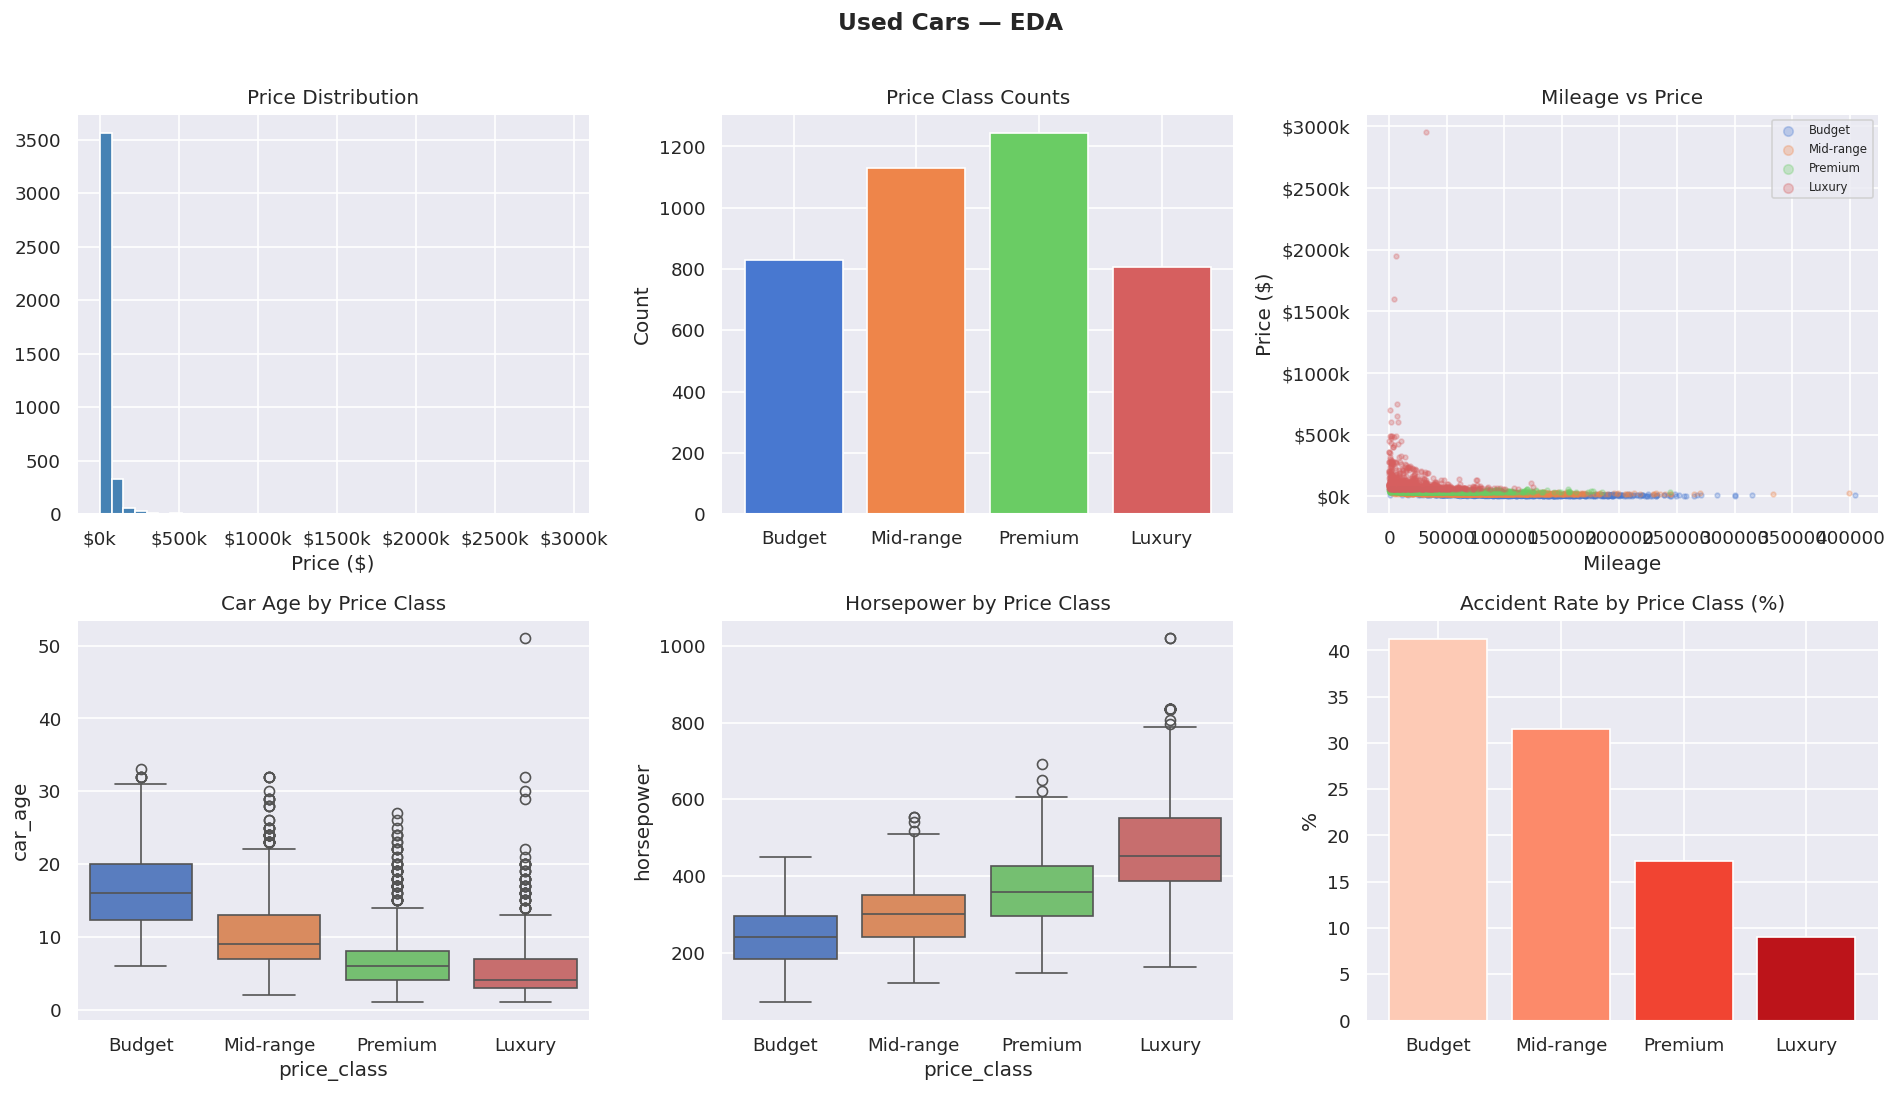

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

axes[0,0].hist(data['price_num'], bins=40, color='steelblue', edgecolor='white')
axes[0,0].set_title('Price Distribution')
axes[0,0].set_xlabel('Price ($)')
axes[0,0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))

vc = data['price_class'].value_counts().sort_index()
axes[0,1].bar(vc.index.astype(str), vc.values, color=sns.color_palette('muted', 4))
axes[0,1].set_title('Price Class Counts')
axes[0,1].set_ylabel('Count')

for cls, col in zip(labels, sns.color_palette('muted', 4)):
    sub = data[data['price_class'] == cls]
    axes[0,2].scatter(sub['mileage_num'], sub['price_num'], alpha=0.3, s=8, color=col, label=cls)
axes[0,2].set_title('Mileage vs Price')
axes[0,2].set_xlabel('Mileage')
axes[0,2].set_ylabel('Price ($)')
axes[0,2].legend(fontsize=7, markerscale=2)
axes[0,2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1000:.0f}k'))

sns.boxplot(data=data, x='price_class', y='car_age',    ax=axes[1,0], palette='muted')
axes[1,0].set_title('Car Age by Price Class')

sns.boxplot(data=data, x='price_class', y='horsepower', ax=axes[1,1], palette='muted')
axes[1,1].set_title('Horsepower by Price Class')

acc_rate = data.groupby('price_class', observed=True)['has_accident'].mean() * 100
axes[1,2].bar(acc_rate.index.astype(str), acc_rate.values, color=sns.color_palette('Reds', 4))
axes[1,2].set_title('Accident Rate by Price Class (%)')
axes[1,2].set_ylabel('%')

plt.suptitle('Used Cars — EDA', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4b. Feature Correlation Analysis

A **Pearson correlation heatmap** of all engineered numeric features helps reveal:
- Which features are **strongly correlated** with the price tier
- **Multicollinearity** between predictors that could affect model training


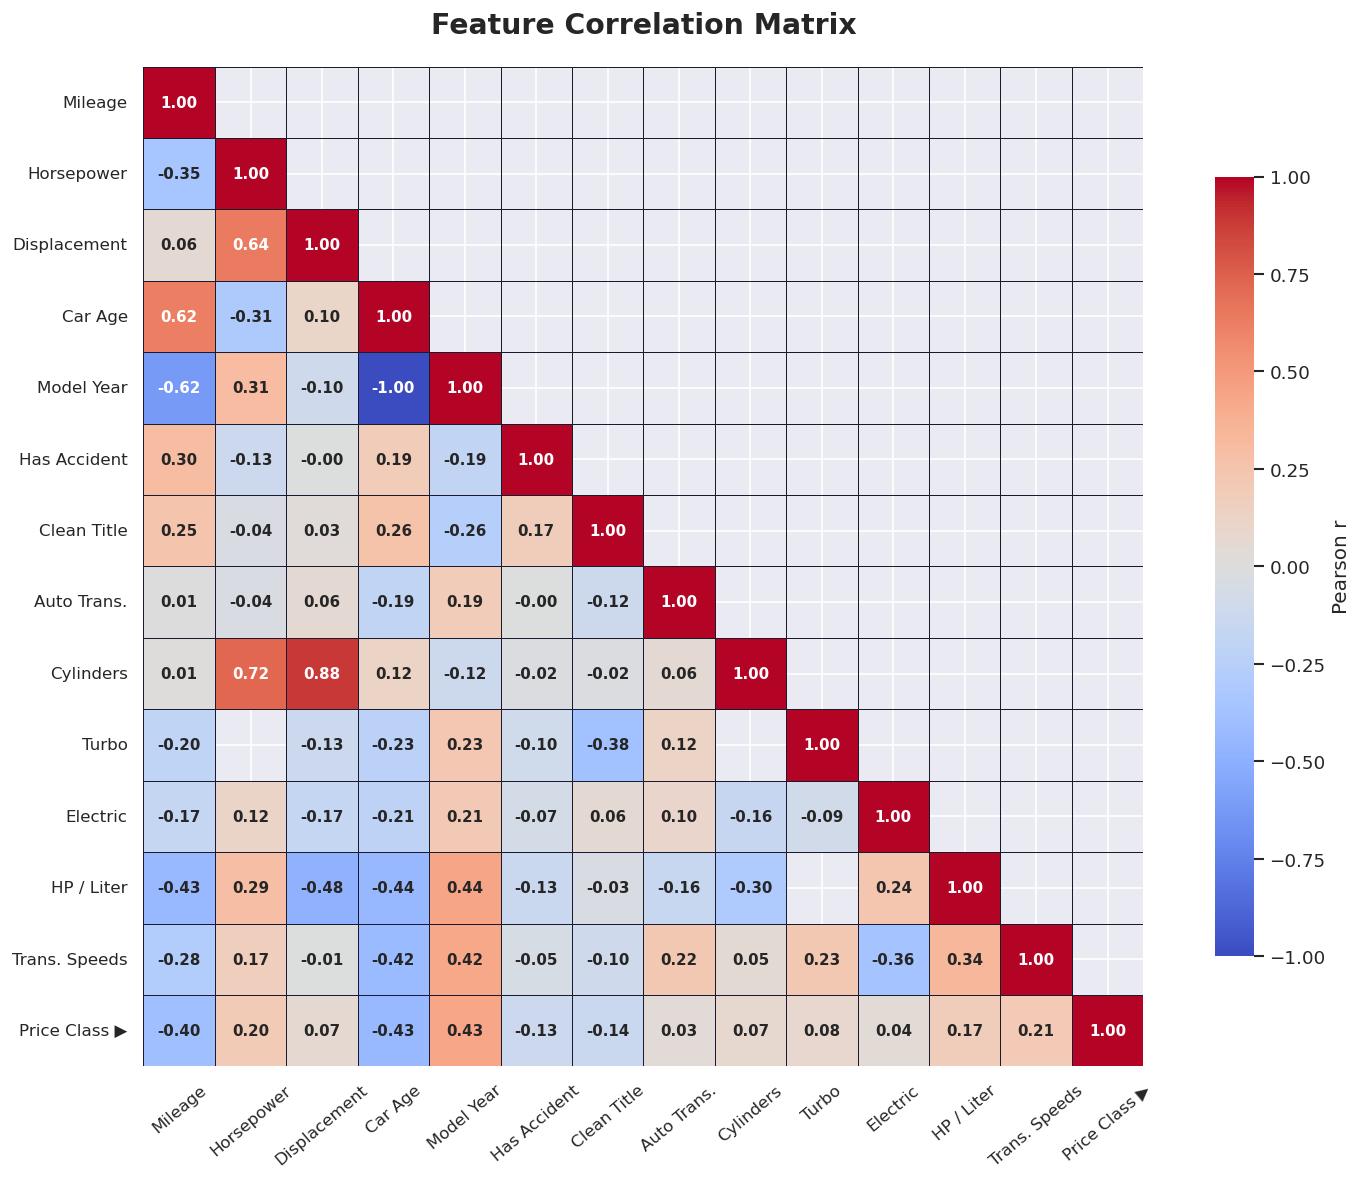


── Correlation with Price Class (sorted by |r|) ──
  Car Age            -0.433  ████████████
  Model Year         +0.433  ████████████
  Mileage            -0.396  ███████████
  Trans. Speeds      +0.206  ██████
  Horsepower         +0.203  ██████
  HP / Liter         +0.174  █████
  Clean Title        -0.138  ████
  Has Accident       -0.125  ███
  Turbo              +0.083  ██
  Cylinders          +0.074  ██
  Displacement       +0.069  ██
  Electric           +0.044  █
  Auto Trans.        +0.032  


In [20]:
# ── Feature Correlation Heatmap ──────────────────────────────────────────────
_corr_numeric = [
    'mileage_num', 'horsepower', 'displacement', 'car_age', 'model_year',
    'has_accident', 'clean_title_flag', 'is_automatic',
    'num_cylinders', 'has_turbo', 'is_electric', 'hp_per_liter', 'trans_speeds',
]

# Encode price_class → integer for correlation
from sklearn.preprocessing import LabelEncoder as _LE
_le = _LE()
_price_enc = _le.fit_transform(data['price_class'].astype(str))

corr_df = data[_corr_numeric].copy()
corr_df['price_class'] = _price_enc
corr_matrix = corr_df.corr()

# Readable axis labels
_label_map = {
    'mileage_num'       : 'Mileage',
    'horsepower'        : 'Horsepower',
    'displacement'      : 'Displacement',
    'car_age'           : 'Car Age',
    'model_year'        : 'Model Year',
    'has_accident'      : 'Has Accident',
    'clean_title_flag'  : 'Clean Title',
    'is_automatic'      : 'Auto Trans.',
    'num_cylinders'     : 'Cylinders',
    'has_turbo'         : 'Turbo',
    'is_electric'       : 'Electric',
    'hp_per_liter'      : 'HP / Liter',
    'trans_speeds'      : 'Trans. Speeds',
    'price_class'       : 'Price Class ▶',
}
corr_matrix.rename(index=_label_map, columns=_label_map, inplace=True)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 10))

_mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)   # hide upper triangle

sns.heatmap(
    corr_matrix,
    mask=_mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    linecolor='#1a1a2e',
    square=True,
    cbar_kws={'shrink': 0.78, 'label': 'Pearson r'},
    ax=ax,
    vmin=-1, vmax=1,
    annot_kws={'size': 9, 'weight': 'bold'},
)

ax.set_title('Feature Correlation Matrix', fontsize=17, fontweight='bold', pad=20)
ax.tick_params(axis='x', rotation=40, labelsize=10)
ax.tick_params(axis='y', rotation=0,  labelsize=10)
fig.tight_layout()
plt.show()

# ── Text summary: correlations with Price Class ───────────────────────────────
_target_col = 'Price Class ▶'
print("\n── Correlation with Price Class (sorted by |r|) ──")
_price_corr = corr_matrix[_target_col].drop(_target_col).sort_values(key=abs, ascending=False)
for feat, val in _price_corr.items():
    if pd.notna(val):
        bar = '█' * int(abs(val) * 30)
        print(f"  {feat:<18} {val:+.3f}  {bar}")


## 5. Feature Selection & Train/Test Split

In [21]:
NUMERIC_FEATURES = [
    'mileage_num', 'horsepower', 'displacement', 'car_age', 'model_year',
    'has_accident', 'clean_title_flag', 'is_automatic',
    'num_cylinders', 'has_turbo', 'is_electric', 'hp_per_liter',
    'trans_speeds',
]

CATEGORICAL_FEATURES = ['brand', 'model', 'fuel_type']
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TARGET = 'price_class'

X = data[ALL_FEATURES].copy()
y = data[TARGET].copy()

mask = y.notna()
X, y = X[mask], y[mask]
y = y.astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print('Class balance (train):')
print(pd.Series(y_train).value_counts())

CLASS_NAMES = sorted(y_train.unique())
print('Classes:', CLASS_NAMES)

Train: (3207, 16), Test: (802, 16)
Class balance (train):
price_class
Premium      995
Mid-range    904
Budget       664
Luxury       644
Name: count, dtype: int64
Classes: ['Budget', 'Luxury', 'Mid-range', 'Premium']


## 6. Preprocessing Pipeline

In [22]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# Ordinal encoding avoids high-dimensional sparse matrices —
# preferred by gradient boosting (especially LightGBM)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False, max_categories=50))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,    NUMERIC_FEATURES),
    ('cat', categorical_transformer, CATEGORICAL_FEATURES)
])

# Encode labels as integers for XGBoost / LightGBM
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)
print('Label mapping:', dict(zip(le.classes_, le.transform(le.classes_))))
print('Preprocessor built ✓')

Label mapping: {'Budget': np.int64(0), 'Luxury': np.int64(1), 'Mid-range': np.int64(2), 'Premium': np.int64(3)}
Preprocessor built ✓


## 7. Boosting Models

### 7a. XGBoost
XGBoost builds trees **sequentially**, each correcting the residual errors of the previous ensemble. It uses regularisation (L1/L2), column subsampling, and efficient histogram splits.


In [23]:
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(
        n_estimators       = 400,
        max_depth          = 6,
        learning_rate      = 0.05,
        subsample          = 0.8,
        colsample_bytree   = 0.8,
        gamma              = 0.1,
        reg_alpha          = 0.1,      # L1
        reg_lambda         = 1.0,      # L2
        use_label_encoder  = False,
        eval_metric        = 'mlogloss',
        random_state       = SEED,
        n_jobs             = -1
    ))
])

xgb_pipeline.fit(X_train, y_train_enc)
print('XGBoost trained ✓')

XGBoost trained ✓


### 7b. LightGBM
LightGBM uses **leaf-wise** tree growth (vs depth-wise in XGBoost) and Gradient-based One-Side Sampling (GOSS), making it significantly faster on large datasets while often matching or exceeding accuracy.


In [24]:
lgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', lgb.LGBMClassifier(
        n_estimators    = 400,
        max_depth       = -1,       # unlimited; controlled by num_leaves
        num_leaves      = 63,
        learning_rate   = 0.05,
        subsample       = 0.8,
        colsample_bytree= 0.8,
        reg_alpha       = 0.1,
        reg_lambda      = 1.0,
        class_weight    = 'balanced',
        random_state    = SEED,
        n_jobs          = -1,
        verbose         = -1
    ))
])

lgb_pipeline.fit(X_train, y_train_enc)
print('LightGBM trained ✓')

LightGBM trained ✓


### 7c. Gradient Boosting Classifier (sklearn baseline)
The original sklearn `GradientBoostingClassifier` — slower but interpretable default. Uses CART trees and shrinkage (learning rate) as a regulariser.


In [25]:
from sklearn.multiclass import OneVsRestClassifier

# sklearn GBC is inherently multiclass but wrap for consistent API
gb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(
        n_estimators   = 200,
        max_depth      = 5,
        learning_rate  = 0.05,
        subsample      = 0.8,
        max_features   = 'sqrt',
        random_state   = SEED
    ))
])

gb_pipeline.fit(X_train, y_train)   # sklearn GBC accepts string labels
print('Gradient Boosting trained ✓')

Gradient Boosting trained ✓


## 8. Evaluation — All Metrics

In [26]:
def evaluate_model(name, pipeline, X_te, y_te_str, y_te_enc,
                   le, class_names, use_encoded=True):
    """
    use_encoded=True  -> pipeline outputs integer labels (XGB / LGB)
    use_encoded=False -> pipeline outputs string labels (sklearn GBC)
    """
    print(f'\n{"="*60}')
    print(f'  MODEL: {name}')
    print(f'{"="*60}')

    if use_encoded:
        y_pred_enc = pipeline.predict(X_te)
        y_pred     = le.inverse_transform(y_pred_enc)
        y_prob     = pipeline.predict_proba(X_te)
    else:
        y_pred = pipeline.predict(X_te)
        y_prob = pipeline.predict_proba(X_te)

    y_te = y_te_str

    acc      = accuracy_score(y_te, y_pred)
    f1_mac   = f1_score(y_te, y_pred, average='macro')
    f1_mic   = f1_score(y_te, y_pred, average='micro')
    f1_wt    = f1_score(y_te, y_pred, average='weighted')
    prec_mac = precision_score(y_te, y_pred, average='macro')
    prec_wt  = precision_score(y_te, y_pred, average='weighted')
    rec_mac  = recall_score(y_te, y_pred, average='macro')
    rec_wt   = recall_score(y_te, y_pred, average='weighted')

    y_bin = label_binarize(y_te, classes=class_names)
    roc   = roc_auc_score(y_bin, y_prob, multi_class='ovr', average='macro')

    metrics = {
        'Accuracy'              : acc,
        'F1 (Macro)'            : f1_mac,
        'F1 (Micro)'            : f1_mic,
        'F1 (Weighted)'         : f1_wt,
        'Precision (Macro)'     : prec_mac,
        'Precision (Weighted)'  : prec_wt,
        'Recall (Macro)'        : rec_mac,
        'Recall (Weighted)'     : rec_wt,
        'ROC-AUC (OvR Macro)'   : roc,
    }

    print('\n📊 Metrics Summary:')
    for k, v in metrics.items():
        print(f'  {k:<28}: {v:.4f}')

    print('\n📋 Classification Report:')
    print(classification_report(y_te, y_pred, target_names=class_names))

    return y_pred, y_prob, metrics

xgb_pred, xgb_prob, xgb_metrics = evaluate_model(
    'XGBoost', xgb_pipeline, X_test, y_test, y_test_enc, le, CLASS_NAMES, use_encoded=True)

lgb_pred, lgb_prob, lgb_metrics = evaluate_model(
    'LightGBM', lgb_pipeline, X_test, y_test, y_test_enc, le, CLASS_NAMES, use_encoded=True)

gb_pred, gb_prob, gb_metrics = evaluate_model(
    'Gradient Boosting (sklearn)', gb_pipeline, X_test, y_test, y_test_enc, le, CLASS_NAMES, use_encoded=False)


  MODEL: XGBoost

📊 Metrics Summary:
  Accuracy                    : 0.7880
  F1 (Macro)                  : 0.7946
  F1 (Micro)                  : 0.7880
  F1 (Weighted)               : 0.7885
  Precision (Macro)           : 0.8017
  Precision (Weighted)        : 0.7912
  Recall (Macro)              : 0.7901
  Recall (Weighted)           : 0.7880
  ROC-AUC (OvR Macro)         : 0.9494

📋 Classification Report:
              precision    recall  f1-score   support

      Budget       0.81      0.82      0.81       166
      Luxury       0.91      0.80      0.85       161
   Mid-range       0.73      0.71      0.72       226
     Premium       0.76      0.83      0.79       249

    accuracy                           0.79       802
   macro avg       0.80      0.79      0.79       802
weighted avg       0.79      0.79      0.79       802


  MODEL: LightGBM

📊 Metrics Summary:
  Accuracy                    : 0.7718
  F1 (Macro)                  : 0.7804
  F1 (Micro)                  : 0

## 9. Confusion Matrices

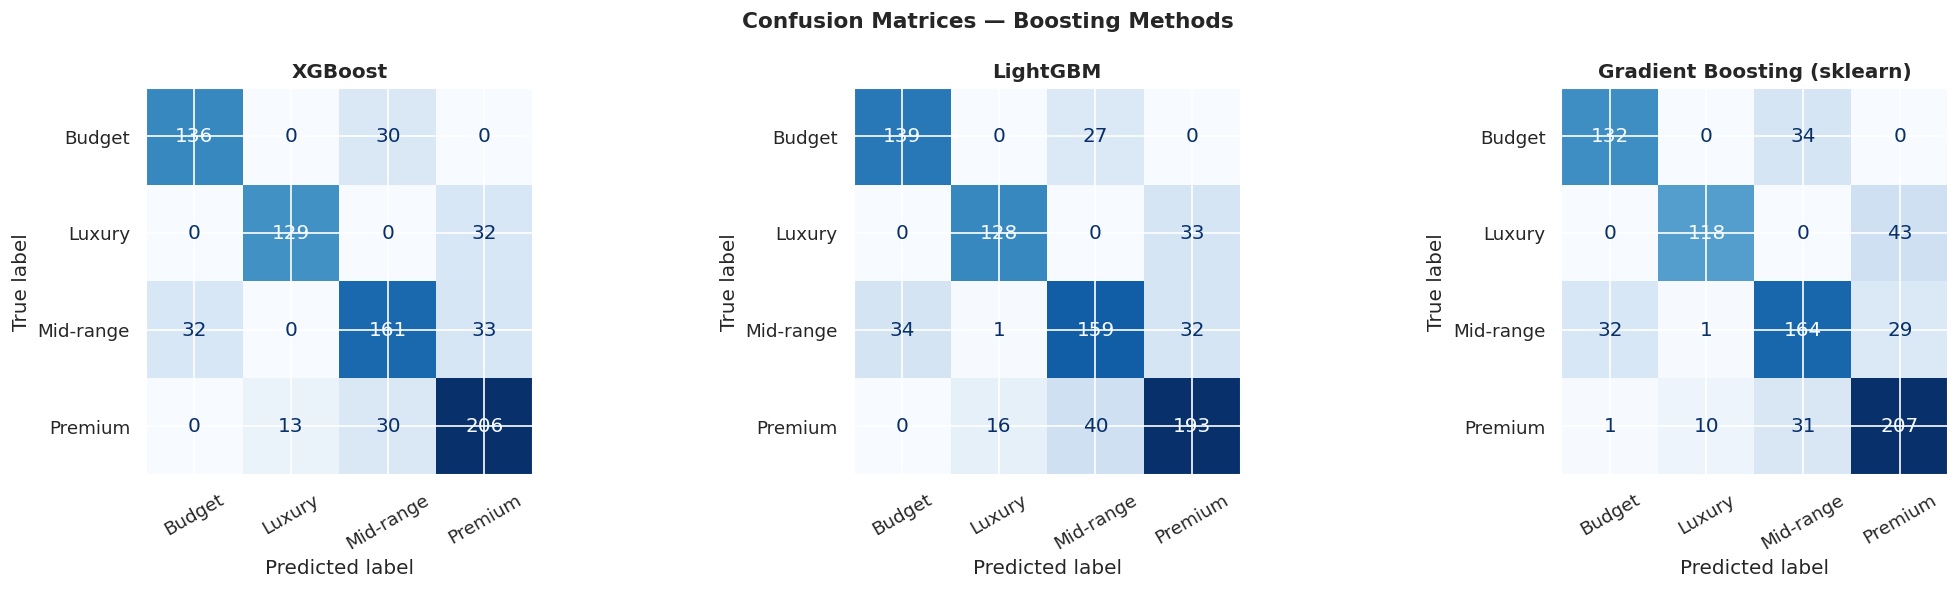

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, pred, title in zip(
    axes,
    [xgb_pred, lgb_pred, gb_pred],
    ['XGBoost', 'LightGBM', 'Gradient Boosting (sklearn)']
):
    cm   = confusion_matrix(y_test, pred, labels=CLASS_NAMES)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Confusion Matrices — Boosting Methods', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. ROC Curves (One-vs-Rest)

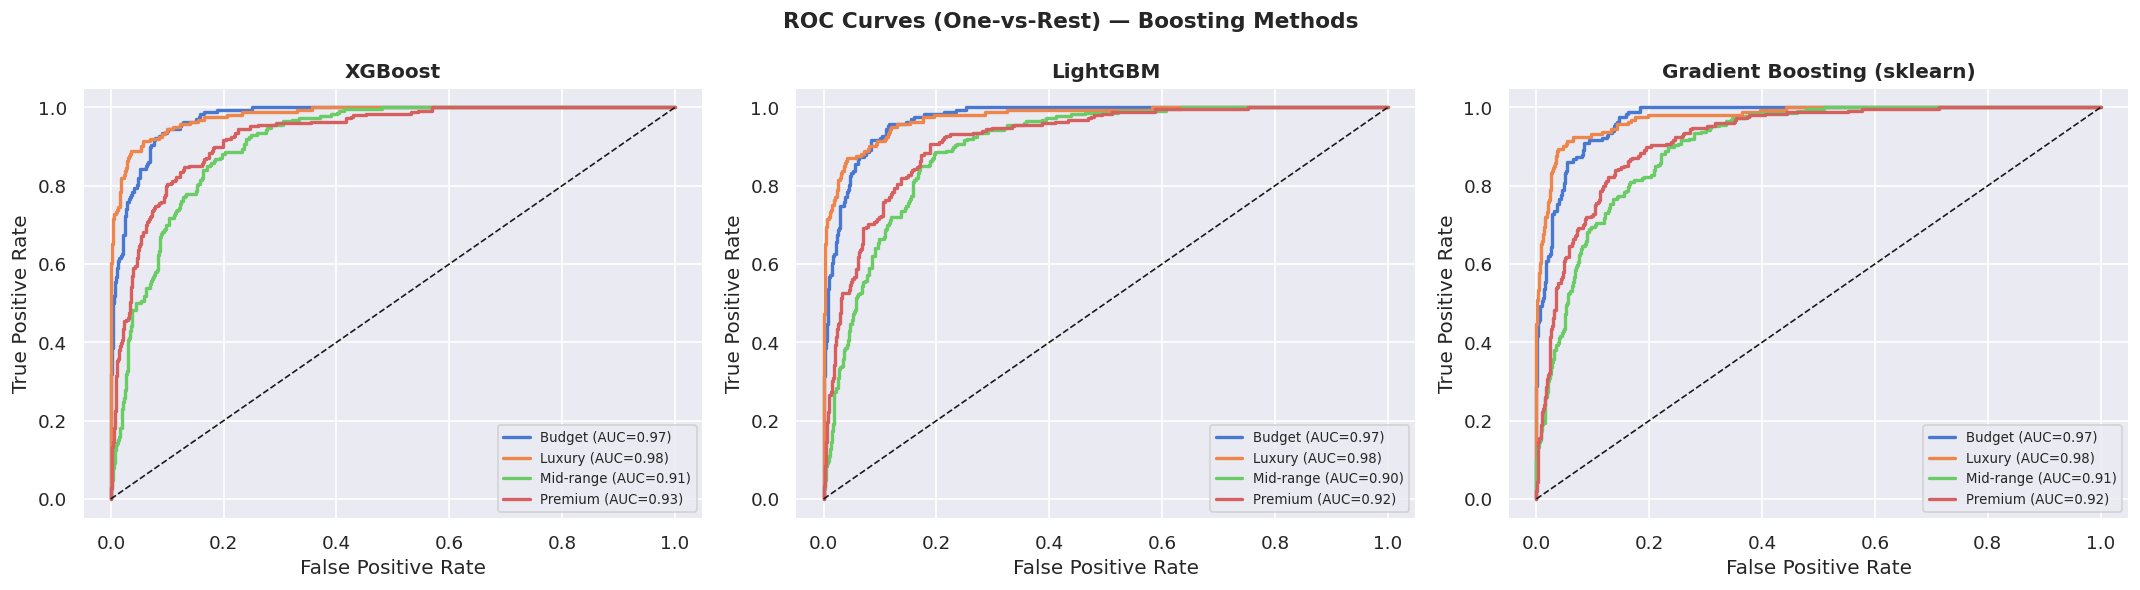

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
y_bin   = label_binarize(y_test, classes=CLASS_NAMES)
colors  = sns.color_palette('muted', len(CLASS_NAMES))

for ax, prob, title in zip(
    axes,
    [xgb_prob, lgb_prob, gb_prob],
    ['XGBoost', 'LightGBM', 'Gradient Boosting (sklearn)']
):
    for i, (cls, col) in enumerate(zip(CLASS_NAMES, colors)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], prob[:, i])
        roc_val     = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=2, color=col, label=f'{cls} (AUC={roc_val:.2f})')
    ax.plot([0,1],[0,1], 'k--', lw=1)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(fontsize=8)

plt.suptitle('ROC Curves (One-vs-Rest) — Boosting Methods', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Feature Importance

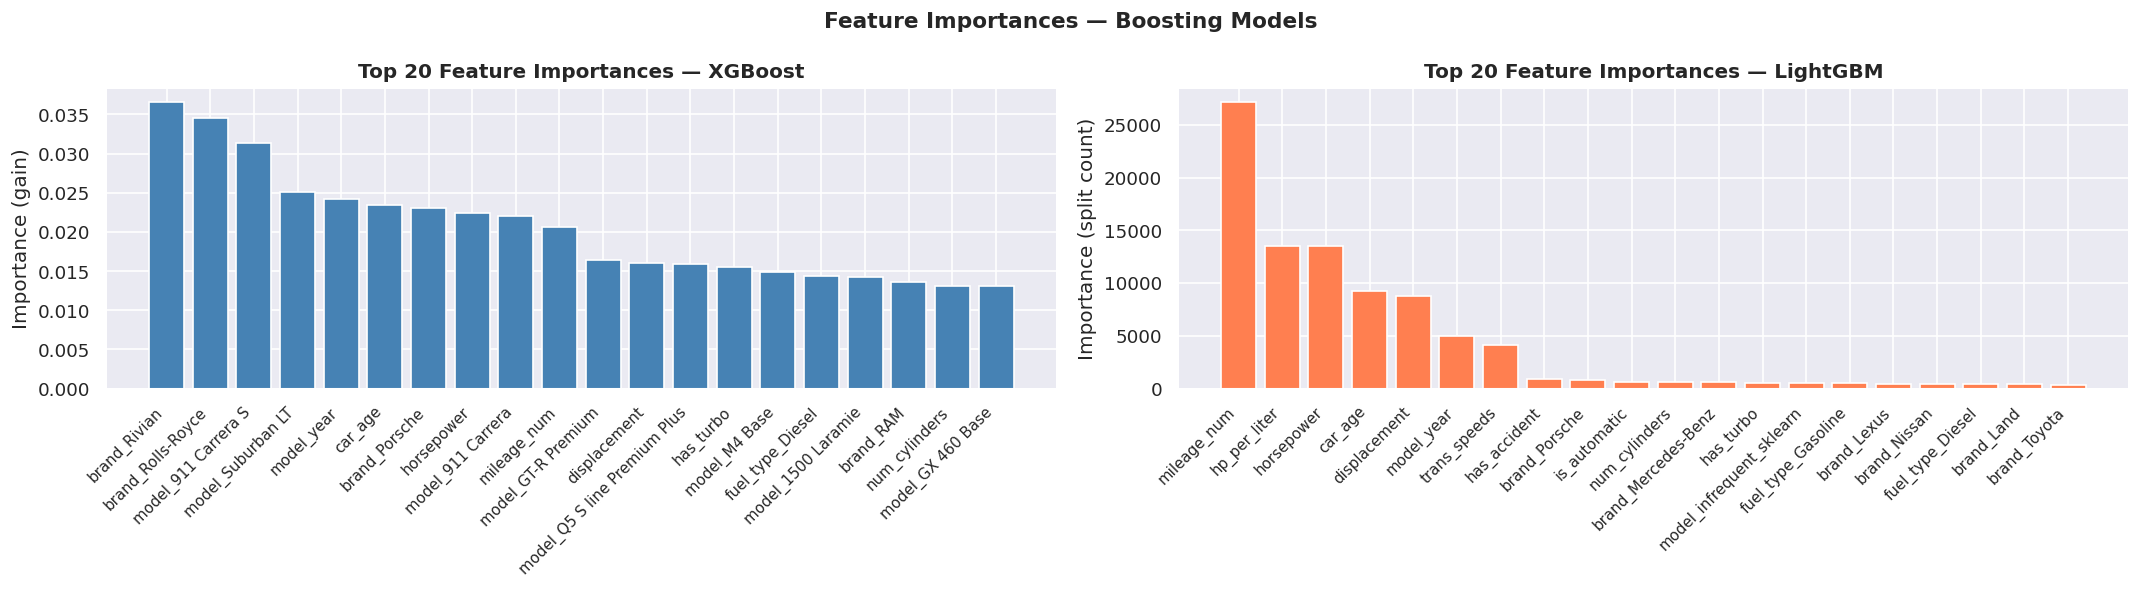

In [29]:
# ── XGBoost feature importance ──
xgb_clf = xgb_pipeline.named_steps['classifier']
pre     = xgb_pipeline.named_steps['preprocessor']

ohe_cols   = list(pre.named_transformers_['cat'].named_steps['ohe'].get_feature_names_out(CATEGORICAL_FEATURES))
feat_names = NUMERIC_FEATURES + ohe_cols

importances = xgb_clf.feature_importances_
indices     = np.argsort(importances)[::-1][:20]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

axes[0].bar(range(len(indices)), importances[indices], color='steelblue', edgecolor='white')
axes[0].set_xticks(range(len(indices)))
axes[0].set_xticklabels([feat_names[i] for i in indices], rotation=45, ha='right', fontsize=9)
axes[0].set_title('Top 20 Feature Importances — XGBoost', fontweight='bold')
axes[0].set_ylabel('Importance (gain)')

# ── LightGBM feature importance ──
lgb_clf     = lgb_pipeline.named_steps['classifier']
lgb_imp     = lgb_clf.feature_importances_
lgb_indices = np.argsort(lgb_imp)[::-1][:20]

axes[1].bar(range(len(lgb_indices)), lgb_imp[lgb_indices], color='coral', edgecolor='white')
axes[1].set_xticks(range(len(lgb_indices)))
axes[1].set_xticklabels([feat_names[i] for i in lgb_indices], rotation=45, ha='right', fontsize=9)
axes[1].set_title('Top 20 Feature Importances — LightGBM', fontweight='bold')
axes[1].set_ylabel('Importance (split count)')

plt.suptitle('Feature Importances — Boosting Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 12. Model Comparison

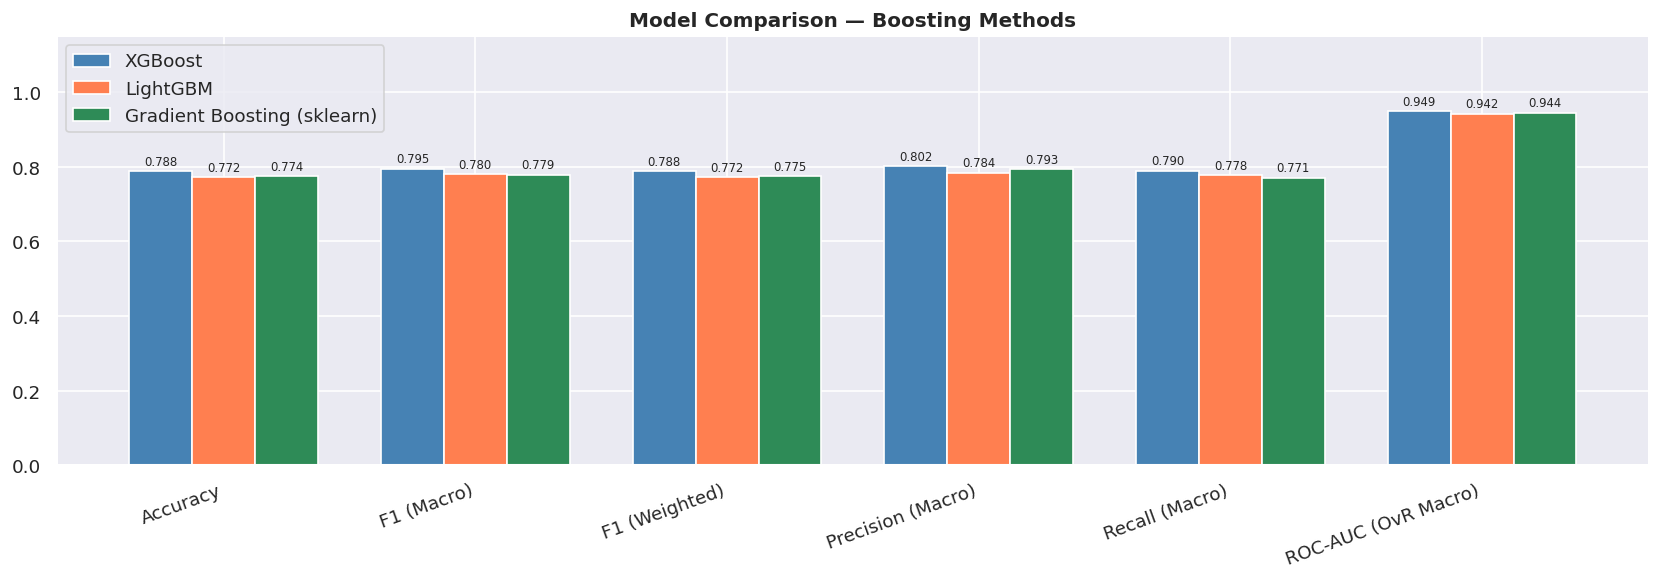


✅ Boosting Pipeline Complete!


In [30]:
compare_keys = ['Accuracy', 'F1 (Macro)', 'F1 (Weighted)',
                'Precision (Macro)', 'Recall (Macro)', 'ROC-AUC (OvR Macro)']

xgb_vals = [xgb_metrics[k] for k in compare_keys]
lgb_vals = [lgb_metrics[k] for k in compare_keys]
gb_vals  = [gb_metrics[k]  for k in compare_keys]

x     = np.arange(len(compare_keys))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 5))
b1 = ax.bar(x - width,   xgb_vals, width, label='XGBoost',               color='steelblue', edgecolor='white')
b2 = ax.bar(x,           lgb_vals, width, label='LightGBM',              color='coral',     edgecolor='white')
b3 = ax.bar(x + width,   gb_vals,  width, label='Gradient Boosting (sklearn)', color='seagreen',  edgecolor='white')

for bars in [b1, b2, b3]:
    ax.bar_label(bars, fmt='%.3f', fontsize=7, padding=2)

ax.set_xticks(x)
ax.set_xticklabels(compare_keys, rotation=20, ha='right')
ax.set_ylim(0, 1.15)
ax.set_title('Model Comparison — Boosting Methods', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print('\n✅ Boosting Pipeline Complete!')